# Nixtla Time Series Design from Raw Alibaba Traces

This notebook prepares raw `batch_task.csv` and `batch_instance.csv` into a Nixtla-ready panel dataset, then analyzes forecast outputs when available.

It keeps the raw files as the source of truth and uses explicit, reproducible transforms for:
- job-level series
- sequential instance ordering
- parallel-aware aggregation
- schema validation and export
- forecast result analysis

## Executive Summary

1. This notebook builds a Nixtla-ready panel from Alibaba traces at the job-series level and evaluates multiple statistical forecast models.
2. The current final run uses a synthetic per-job timeline (`ds` from `instance_idx`), not raw wall-clock `start_time`.
3. In full-coverage results, `autoarima` has the lowest MAE but very low coverage; in fair common-series comparison, `naive` is best.
4. A coverage-aware selection score picks `naive` as the most practical default model in this run.
5. The generated artifacts (`metrics_summary`, `metrics_common_series`, `model_selection_score`, `metrics_by_fold`, `season_sweep`, and `run_info`) provide a reproducible evaluation package for thesis reporting.

## Key Definitions

- `unique_id`: the series identifier; here it is the `job_id`.
- `ds`: the time index used by Nixtla. In this notebook it is a synthetic, monotonic second-based timeline derived from `instance_idx`.
- `y`: the target variable to forecast; here it is aggregated CPU usage (`cpu_max`) per job-step.
- `coverage`: the fraction of validation rows or series a model actually predicts.
- `selection score`: a combined ranking that balances accuracy and coverage so a model can be compared more fairly across different forecast spans.

In [19]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

    # Fallback metrics keep the notebook runnable if sklearn is unavailable.
    def mean_absolute_error(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        return np.mean(np.abs(y_true - y_pred))

    def mean_squared_error(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        return np.mean((y_true - y_pred) ** 2)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
np.random.seed(42)

BASE_DIR = Path('e:/Cloud_Resource_Optimisation_thesis')
RAW_DIR = BASE_DIR / 'data' / 'raw' / 'clusterdata2018' / 'trace_201708'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
RESULTS_DIR = BASE_DIR / 'results'

STATSFORECAST_VERSION = None
try:
    import statsforecast
    STATSFORECAST_VERSION = getattr(statsforecast, '__version__', 'unknown')
    HAS_STATSFORECAST = True
except Exception:
    HAS_STATSFORECAST = False

try:
    import neuralforecast
    HAS_NEURALFORECAST = True
except Exception:
    HAS_NEURALFORECAST = False

print(f'RAW_DIR              : {RAW_DIR}')
print(f'PROCESSED_DIR        : {PROCESSED_DIR}')
print(f'RESULTS_DIR          : {RESULTS_DIR}')
print(f'Has StatsForecast    : {HAS_STATSFORECAST}')
print(f'StatsForecast version: {STATSFORECAST_VERSION}')
print(f'Has NeuralForecast   : {HAS_NEURALFORECAST}')
print(f'Has scikit-learn     : {HAS_SKLEARN}')

RAW_DIR              : e:\Cloud_Resource_Optimisation_thesis\data\raw\clusterdata2018\trace_201708
PROCESSED_DIR        : e:\Cloud_Resource_Optimisation_thesis\data\processed
RESULTS_DIR          : e:\Cloud_Resource_Optimisation_thesis\results
Has StatsForecast    : True
StatsForecast version: 2.0.3
Has NeuralForecast   : False
Has scikit-learn     : True


## 1. Discover and preview raw files

This notebook uses the raw Alibaba trace files directly. The instance file is headerless and contains 12 columns in this workspace. We keep the ordering explicit so the Nixtla-ready dataset is reproducible and transparent.

In [20]:
raw_files = sorted(RAW_DIR.glob('*.csv'))
print('Raw CSV files:')
for path in raw_files:
    print(f'  - {path.name}')

TASK_COLS = [
    'job_id', 'task_id', 'ntasks', 'priority', 'submitted_time',
    'status', 'plan_cpu', 'plan_mem', 'plan_duration',
    'actual_runtime', 'cpu_count', 'mem_count'
]
INSTANCE_COLS = [
    'job_id', 'task_id', 'machine_id', 'instance_idx',
    'start_time', 'end_time', 'cpu_max', 'cpu_avg',
    'mem_max', 'mem_avg', 'diskio_max', 'diskio_avg'
]

print('\nPreview batch_task.csv:')
task_preview = pd.read_csv(RAW_DIR / 'batch_task.csv', header=None, nrows=5, names=TASK_COLS)
print(task_preview.head().to_string(index=False))

print('\nPreview batch_instance.csv:')
instance_preview = pd.read_csv(RAW_DIR / 'batch_instance.csv', header=None, nrows=5)
print(instance_preview.head().to_string(index=False))
print(f'\nPreview instance column count: {instance_preview.shape[1]}')

Raw CSV files:
  - batch_instance - Copy.csv
  - batch_instance.csv
  - batch_task - Copy.csv
  - batch_task.csv
  - container_event.csv
  - container_usage.csv
  - server_event.csv
  - server_usage.csv

Preview batch_task.csv:
 job_id  task_id  ntasks  priority  submitted_time     status  plan_cpu  plan_mem  plan_duration  actual_runtime  cpu_count  mem_count
   6459     6524       3         4           15740 Terminated      50.0  0.007957            NaN             NaN        NaN        NaN
   6457     6533       3         5               1 Terminated      50.0  0.004395            NaN             NaN        NaN        NaN
   6036     6046       4         7             393    Waiting       NaN       NaN            NaN             NaN        NaN        NaN
   6036     6046       4         6             452    Waiting       NaN       NaN            NaN             NaN        NaN        NaN
  10719    11332      15        67            1705 Terminated      50.0  0.005736            NaN 

## 2. Normalize identifiers and build the Nixtla-ready time axis

The raw trace does not provide a clean absolute wall-clock timeline for the instance file in this workspace, so the safe design is a synthetic, monotonic time axis per job. We keep sequential instance order by `instance_idx`, and we aggregate same-step parallel instances into a single step with parallel-aware summary features.

In [21]:
task_df = pd.read_csv(RAW_DIR / 'batch_task.csv', header=None, names=TASK_COLS, dtype={'job_id': 'int64', 'task_id': 'int64'})
instance_df = pd.read_csv(RAW_DIR / 'batch_instance.csv', header=None, names=INSTANCE_COLS, dtype={'job_id': 'int64', 'task_id': 'int64'})

for col in ['start_time', 'end_time', 'cpu_max', 'cpu_avg', 'mem_max', 'mem_avg', 'diskio_max', 'diskio_avg']:
    instance_df[col] = pd.to_numeric(instance_df[col], errors='coerce')

for col in ['submitted_time', 'plan_cpu', 'plan_mem', 'plan_duration', 'actual_runtime', 'cpu_count', 'mem_count']:
    task_df[col] = pd.to_numeric(task_df[col], errors='coerce')

trace_base = pd.Timestamp('2017-07-01', tz='UTC')

plan_df = task_df.groupby('job_id', as_index=False).agg(
    plan_cpu=('plan_cpu', 'first'),
    plan_mem=('plan_mem', 'first'),
    ntasks=('ntasks', 'first')
)
plan_df['plan_cpu_cores'] = plan_df['plan_cpu'] / 100.0

step_df = (
    instance_df
    .assign(step_no=lambda d: d['instance_idx'].fillna(0).astype(int))
    .groupby(['job_id', 'step_no'], as_index=False)
    .agg(
        y=('cpu_max', 'sum'),
        cpu_max_mean=('cpu_max', 'mean'),
        cpu_max_max=('cpu_max', 'max'),
        cpu_avg_mean=('cpu_avg', 'mean'),
        mem_max_mean=('mem_max', 'mean'),
        mem_avg_mean=('mem_avg', 'mean'),
        parallel_instance_count=('task_id', 'count'),
        parallel_task_count=('task_id', 'nunique')
    )
)

step_df['unique_id'] = step_df['job_id'].astype(str)
step_df['ds'] = trace_base + pd.to_timedelta(step_df['step_no'], unit='s')
step_df['series_kind'] = 'job_parallel_aggregate'

nixtla_df = step_df.merge(plan_df, on='job_id', how='left')
nixtla_df = nixtla_df[
    [
        'unique_id', 'ds', 'y',
        'cpu_max_mean', 'cpu_max_max', 'cpu_avg_mean', 'mem_max_mean', 'mem_avg_mean',
        'parallel_instance_count', 'parallel_task_count', 'plan_cpu', 'plan_mem', 'plan_cpu_cores',
        'job_id', 'step_no', 'series_kind'
    ]
].sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(f'Raw task rows     : {len(task_df):,}')
print(f'Raw instance rows : {len(instance_df):,}')
print(f'Nixtla rows       : {len(nixtla_df):,}')
print(f'Unique jobs       : {nixtla_df["unique_id"].nunique():,}')
print(f'Key columns       : {list(nixtla_df.columns[:8])}')
print('\nSample Nixtla-ready rows:')
print(nixtla_df.head(8).to_string(index=False))

Raw task rows     : 80,553
Raw instance rows : 16,094,656
Nixtla rows       : 232,727
Unique jobs       : 71,265
Key columns       : ['unique_id', 'ds', 'y', 'cpu_max_mean', 'cpu_max_max', 'cpu_avg_mean', 'mem_max_mean', 'mem_avg_mean']

Sample Nixtla-ready rows:
unique_id                        ds   y  cpu_max_mean  cpu_max_max  cpu_avg_mean  mem_max_mean  mem_avg_mean  parallel_instance_count  parallel_task_count  plan_cpu  plan_mem  plan_cpu_cores  job_id  step_no            series_kind
       -1 2017-07-01 03:39:08+00:00   2           1.0            1           1.0      0.955000      0.955000                        2                    1       NaN       NaN             NaN      -1    13148 job_parallel_aggregate
      -10 2017-07-01 03:39:07+00:00   1           1.0            1           1.0      1.000000      0.980000                        1                    1       NaN       NaN             NaN     -10    13147 job_parallel_aggregate
      -10 2017-07-01 10:19:51+00:00   7    

## 3. Validate and save the Nixtla dataset

The exported table uses the standard long-format schema expected by Nixtla-style time series workflows: `unique_id`, `ds`, `y`, plus exogenous regressors. We also save a metadata file that records the frequency, the synthetic timeline assumption, and the meaning of each feature.

In [22]:
required_cols = ['unique_id', 'ds', 'y']
missing_required = [col for col in required_cols if col not in nixtla_df.columns]
if missing_required:
    raise ValueError(f'Missing required Nixtla columns: {missing_required}')

if nixtla_df[['unique_id', 'ds']].isna().any().any():
    raise ValueError('unique_id/ds contains nulls')

if nixtla_df.duplicated(['unique_id', 'ds']).any():
    duplicate_count = nixtla_df.duplicated(['unique_id', 'ds']).sum()
    raise ValueError(f'Duplicate unique_id+ds rows found: {duplicate_count}')

if (nixtla_df['y'] < 0).any():
    print('Warning: negative y values found; keeping them because they may be valid after aggregation.')

nixtla_csv = PROCESSED_DIR / 'nixtla_job_panel.csv'
nixtla_parquet = PROCESSED_DIR / 'nixtla_job_panel.parquet'
metadata_path = PROCESSED_DIR / 'nixtla_job_panel_metadata.json'
series_map_path = PROCESSED_DIR / 'nixtla_job_series_map.csv'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

nixtla_df.to_csv(nixtla_csv, index=False)
try:
    nixtla_df.to_parquet(nixtla_parquet, index=False)
    parquet_status = 'saved'
except Exception as exc:
    parquet_status = f'not saved ({exc})'

series_map = nixtla_df[['unique_id', 'job_id']].drop_duplicates().sort_values(['unique_id'])
series_map.to_csv(series_map_path, index=False)

metadata = {
    'source_files': ['batch_task.csv', 'batch_instance.csv'],
    'base_timestamp_utc': str(trace_base),
    'freq': 'S',
    'timeline_type': 'synthetic_relative_seconds',
    'series_kind': 'job_parallel_aggregate',
    'target_column': 'y',
    'required_columns': required_cols,
    'feature_columns': [
        'cpu_max_mean', 'cpu_max_max', 'cpu_avg_mean', 'mem_max_mean', 'mem_avg_mean',
        'parallel_instance_count', 'parallel_task_count', 'plan_cpu', 'plan_mem', 'plan_cpu_cores'
    ],
    'row_count': int(len(nixtla_df)),
    'series_count': int(nixtla_df['unique_id'].nunique())
}
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'CSV saved    : {nixtla_csv}')
print(f'Parquet saved: {nixtla_parquet} [{parquet_status}]')
print(f'Metadata     : {metadata_path}')
print(f'Series map   : {series_map_path}')
print('\nPer-series row count summary:')
print(nixtla_df.groupby('unique_id').size().describe().round(2))

CSV saved    : e:\Cloud_Resource_Optimisation_thesis\data\processed\nixtla_job_panel.csv
Parquet saved: e:\Cloud_Resource_Optimisation_thesis\data\processed\nixtla_job_panel.parquet [saved]
Metadata     : e:\Cloud_Resource_Optimisation_thesis\data\processed\nixtla_job_panel_metadata.json
Series map   : e:\Cloud_Resource_Optimisation_thesis\data\processed\nixtla_job_series_map.csv

Per-series row count summary:
count    71265.00
mean         3.27
std         34.92
min          1.00
25%          1.00
50%          2.00
75%          4.00
max       9273.00
dtype: float64


## 4. Load the Nixtla dataset and evaluate forecast results

This section prepares a reproducible temporal split, then either loads forecast artifacts created by a Nixtla run or produces a simple baseline forecast so the notebook always has an analysis path.

### What This Final Evaluation Does

This final run section evaluates multiple forecasting models while handling two practical issues:

1. Stale artifacts: it regenerates forecasts by default so results are from the current code and settings.
2. Uneven model coverage: some models only predict for a subset of series, so we report both full-coverage metrics and fair common-series metrics.

Outputs produced in this section:
- all-predictions metrics table,
- fair common-series metrics table,
- coverage-aware model selection score table,
- rolling-origin baseline backtest,
- seasonal naive sweep.

In [23]:
horizon = 8
season_length = 5
max_backtest_folds = 3
candidate_season_lengths = [2, 4, 5, 8, 16, 32]
force_regenerate_forecasts = True  # Final-run default: avoid stale artifacts.

nixtla_df = pd.read_csv(PROCESSED_DIR / 'nixtla_job_panel.csv', parse_dates=['ds'])
nixtla_df = nixtla_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

series_lengths = nixtla_df.groupby('unique_id').size()
valid_series = series_lengths[series_lengths >= (horizon + max_backtest_folds + 1)].index
nixtla_eval_df = nixtla_df[nixtla_df['unique_id'].isin(valid_series)].copy()

if nixtla_eval_df.empty:
    raise ValueError(
        f'No series meet minimum length requirement ({horizon + max_backtest_folds + 1}). '
        'Lower horizon or revisit panel construction.'
    )

train_parts = []
val_parts = []
for unique_id, group in nixtla_eval_df.groupby('unique_id'):
    group = group.sort_values('ds')
    train_parts.append(group.iloc[:-horizon])
    val_parts.append(group.iloc[-horizon:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)

train_split_path = PROCESSED_DIR / 'nixtla_train_split.csv'
val_split_path = PROCESSED_DIR / 'nixtla_val_split.csv'
train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)

print(f'Train rows  : {len(train_df):,}')
print(f'Val rows    : {len(val_df):,}')
print(f'Series used : {train_df["unique_id"].nunique():,}')
print(f'Horizon     : {horizon}')

forecast_artifact_path = RESULTS_DIR / 'nixtla_forecasts.csv'
forecast_rows = []
statsforecast_models_used = []
forecast_source = 'artifact'

if force_regenerate_forecasts and forecast_artifact_path.exists():
    forecast_artifact_path.unlink()
    print('Removed previous forecast artifact for clean final run.')

if forecast_artifact_path.exists():
    forecast_df = pd.read_csv(forecast_artifact_path, parse_dates=['ds'])
    if 'model' not in forecast_df.columns:
        forecast_df['model'] = 'forecast'
    if 'y_hat' not in forecast_df.columns:
        candidate_cols = [
            col for col in forecast_df.columns
            if col.startswith('yhat') or col.startswith('pred') or col.startswith('forecast')
        ]
        if candidate_cols:
            forecast_df = forecast_df.rename(columns={candidate_cols[0]: 'y_hat'})
    required_forecast_cols = {'unique_id', 'ds', 'model', 'y_hat'}
    missing_forecast_cols = sorted(required_forecast_cols - set(forecast_df.columns))
    if missing_forecast_cols:
        raise ValueError(
            f'Forecast artifact missing required columns: {missing_forecast_cols}. '
            f'Available columns: {list(forecast_df.columns)}'
        )
    forecast_long = forecast_df[['unique_id', 'ds', 'model', 'y_hat']].copy()
    forecast_long['model'] = forecast_long['model'].astype(str).str.lower()
    statsforecast_models_used = sorted(forecast_long['model'].dropna().unique().tolist())
    print(f'Loaded existing forecast artifact: {forecast_artifact_path}')
else:
    print('No forecast artifact found; creating forecasts.')
    if HAS_STATSFORECAST:
        try:
            from statsforecast import StatsForecast
            from statsforecast.models import AutoARIMA, AutoETS, HistoricAverage, Naive, SeasonalNaive, WindowAverage

            model_frames = []

            # Base fast models on all series.
            base_models = [
                Naive(),
                SeasonalNaive(season_length=season_length),
                HistoricAverage(),
                WindowAverage(window_size=max(2, season_length)),
            ]
            sf_base = StatsForecast(models=base_models, freq='s', n_jobs=-1)
            base_fcst = sf_base.forecast(df=train_df[['unique_id', 'ds', 'y']], h=horizon)
            model_frames.append(base_fcst)

            # Auto models need longer histories; run only on eligible series.
            min_len_for_auto = max(16, 2 * season_length + horizon)
            auto_ids = train_df.groupby('unique_id').size()
            auto_ids = auto_ids[auto_ids >= min_len_for_auto].index
            auto_train = train_df[train_df['unique_id'].isin(auto_ids)][['unique_id', 'ds', 'y']]

            if not auto_train.empty:
                auto_models = [
                    AutoETS(season_length=season_length),
                    AutoARIMA(season_length=season_length),
                ]
                for model in auto_models:
                    try:
                        sf_auto = StatsForecast(models=[model], freq='s', n_jobs=-1)
                        auto_fcst = sf_auto.forecast(df=auto_train, h=horizon)
                        model_frames.append(auto_fcst)
                    except Exception as model_exc:
                        print(f'Skipping model {model}: {model_exc}')
            else:
                print('No series eligible for AutoETS/AutoARIMA under current min length rule.')

            sf_forecast = model_frames[0]
            for frame in model_frames[1:]:
                sf_forecast = sf_forecast.merge(frame, on=['unique_id', 'ds'], how='outer')

            forecast_long = sf_forecast.melt(
                id_vars=['unique_id', 'ds'],
                var_name='model',
                value_name='y_hat'
            )
            forecast_long = forecast_long.dropna(subset=['y_hat'])
            forecast_long['model'] = forecast_long['model'].astype(str).str.lower()
            statsforecast_models_used = sorted(forecast_long['model'].dropna().unique().tolist())
            forecast_source = 'generated_statsforecast'
            forecast_long.to_csv(forecast_artifact_path, index=False)
            print('StatsForecast models completed and artifact saved.')
        except Exception as exc:
            print(f'StatsForecast unavailable at runtime: {exc}')
            HAS_STATSFORECAST = False
    if not HAS_STATSFORECAST:
        forecast_source = 'generated_baseline'
        for unique_id, train_group in train_df.groupby('unique_id'):
            train_group = train_group.sort_values('ds')
            val_group = val_df[val_df['unique_id'] == unique_id].sort_values('ds')
            last_value = train_group['y'].iloc[-1]
            naive_pred = np.repeat(last_value, len(val_group))
            if len(train_group) >= season_length:
                seasonal_source = train_group['y'].iloc[-season_length:].to_numpy()
                seasonal_pred = np.resize(seasonal_source, len(val_group))
            else:
                seasonal_pred = naive_pred
            forecast_rows.append(pd.DataFrame({
                'unique_id': unique_id,
                'ds': val_group['ds'].values,
                'model': 'naive_last',
                'y_hat': naive_pred
            }))
            forecast_rows.append(pd.DataFrame({
                'unique_id': unique_id,
                'ds': val_group['ds'].values,
                'model': 'seasonal_naive',
                'y_hat': seasonal_pred
            }))
        if not forecast_rows:
            raise ValueError('No forecasts were generated from baseline logic.')
        forecast_long = pd.concat(forecast_rows, ignore_index=True)
        forecast_long.to_csv(forecast_artifact_path, index=False)
        print('Fallback baseline forecasts completed and artifact saved.')

# Normalize ds to tz-naive datetime64[ns] in both frames to avoid dtype merge errors
def _to_naive(s):
    s = pd.to_datetime(s)
    if hasattr(s.dt, 'tz') and s.dt.tz is not None:
        return s.dt.tz_convert('UTC').dt.tz_localize(None)
    return s

forecast_long['ds'] = _to_naive(forecast_long['ds'])
val_df = val_df.copy()
val_df['ds'] = _to_naive(val_df['ds'])

forecast_eval = forecast_long.merge(val_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
forecast_eval = forecast_eval.dropna(subset=['y_hat', 'y'])
if forecast_eval.empty:
    raise ValueError('Forecast evaluation table is empty after merge/dropna. Check ds alignment and artifact schema.')


def safe_mape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


def safe_smape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denom = np.abs(actual) + np.abs(predicted)
    mask = denom > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean((2.0 * np.abs(actual[mask] - predicted[mask])) / denom[mask]) * 100


def safe_wape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denom = np.sum(np.abs(actual))
    if denom == 0:
        return np.nan
    return (np.sum(np.abs(actual - predicted)) / denom) * 100


# MASE scale per series from in-sample one-step naive errors
mase_scale = {}
for uid, g in train_df.groupby('unique_id'):
    y_hist = g.sort_values('ds')['y'].to_numpy(dtype=float)
    if len(y_hist) < 2:
        mase_scale[uid] = np.nan
    else:
        denom = np.mean(np.abs(np.diff(y_hist)))
        mase_scale[uid] = np.nan if denom == 0 else denom


def safe_mase(df_model):
    parts = []
    for uid, g in df_model.groupby('unique_id'):
        denom = mase_scale.get(uid, np.nan)
        if pd.isna(denom) or denom == 0:
            continue
        parts.append(np.abs(g['y'].to_numpy(dtype=float) - g['y_hat'].to_numpy(dtype=float)) / denom)
    if not parts:
        return np.nan
    return np.mean(np.concatenate(parts))


total_val_rows = len(val_df)
total_val_series = val_df['unique_id'].nunique()

metrics_table = (
    forecast_eval.groupby('model')
    .apply(lambda g: pd.Series({
        'mae': mean_absolute_error(g['y'], g['y_hat']),
        'rmse': np.sqrt(mean_squared_error(g['y'], g['y_hat'])),
        'wape': safe_wape(g['y'], g['y_hat']),
        'smape': safe_smape(g['y'], g['y_hat']),
        'mase': safe_mase(g),
        'mape': safe_mape(g['y'], g['y_hat']),
        'rows': len(g),
        'series_count': g['unique_id'].nunique(),
        'row_coverage_pct': (len(g) / total_val_rows) * 100.0,
        'series_coverage_pct': (g['unique_id'].nunique() / total_val_series) * 100.0
    }))
    .reset_index()
    .sort_values('mae')
)

metrics_csv = RESULTS_DIR / 'nixtla_metrics_summary.csv'
metrics_table.to_csv(metrics_csv, index=False)


# Fair comparison: restrict to common series available for every model.
model_to_ids = {
    model: set(group['unique_id'].unique())
    for model, group in forecast_eval.groupby('model')
}
common_series_ids = sorted(set.intersection(*model_to_ids.values())) if model_to_ids else []

if common_series_ids:
    forecast_eval_common = forecast_eval[forecast_eval['unique_id'].isin(common_series_ids)].copy()
    metrics_common_table = (
        forecast_eval_common.groupby('model')
        .apply(lambda g: pd.Series({
            'mae': mean_absolute_error(g['y'], g['y_hat']),
            'rmse': np.sqrt(mean_squared_error(g['y'], g['y_hat'])),
            'wape': safe_wape(g['y'], g['y_hat']),
            'smape': safe_smape(g['y'], g['y_hat']),
            'mase': safe_mase(g),
            'mape': safe_mape(g['y'], g['y_hat']),
            'rows': len(g),
            'series_count': g['unique_id'].nunique()
        }))
        .reset_index()
        .sort_values('mae')
    )
else:
    forecast_eval_common = forecast_eval.iloc[0:0].copy()
    metrics_common_table = pd.DataFrame(columns=['model', 'mae', 'rmse', 'wape', 'smape', 'mase', 'mape', 'rows', 'series_count'])

metrics_common_csv = RESULTS_DIR / 'nixtla_metrics_common_series.csv'
metrics_common_table.to_csv(metrics_common_csv, index=False)


# Coverage-aware model selection score.
model_selection_table = metrics_table[['model', 'mae', 'row_coverage_pct', 'series_coverage_pct']].copy()
model_selection_table['coverage_pct'] = (
    model_selection_table['row_coverage_pct'] + model_selection_table['series_coverage_pct']
) / 2.0
model_selection_table['mae_rank'] = model_selection_table['mae'].rank(method='min', ascending=True)
model_selection_table['coverage_rank'] = model_selection_table['coverage_pct'].rank(method='min', ascending=False)

if not metrics_common_table.empty:
    common_mae_map = metrics_common_table.set_index('model')['mae']
    model_selection_table['common_mae'] = model_selection_table['model'].map(common_mae_map)
    model_selection_table['common_mae_rank'] = model_selection_table['common_mae'].rank(method='min', ascending=True)
    model_selection_table['selection_score'] = (
        0.5 * model_selection_table['mae_rank']
        + 0.3 * model_selection_table['coverage_rank']
        + 0.2 * model_selection_table['common_mae_rank']
    )
else:
    model_selection_table['common_mae'] = np.nan
    model_selection_table['common_mae_rank'] = np.nan
    model_selection_table['selection_score'] = (
        0.7 * model_selection_table['mae_rank']
        + 0.3 * model_selection_table['coverage_rank']
    )

model_selection_table = model_selection_table.sort_values('selection_score').reset_index(drop=True)
selected_model = str(model_selection_table.iloc[0]['model'])
model_selection_csv = RESULTS_DIR / 'nixtla_model_selection_score.csv'
model_selection_table.to_csv(model_selection_csv, index=False)


# Rolling-origin backtest with naive baselines for robust model selection
rolling_rows = []
for uid, g in nixtla_eval_df.groupby('unique_id'):
    g = g.sort_values('ds')
    y_full = g['y'].to_numpy(dtype=float)
    n = len(y_full)

    for fold in range(1, max_backtest_folds + 1):
        # Expanding window cutoff; last fold aligns with final holdout horizon
        cutoff = n - horizon - (max_backtest_folds - fold)
        end = cutoff + horizon
        if cutoff < 2 or end > n:
            continue

        y_train = y_full[:cutoff]
        y_val = y_full[cutoff:end]

        naive_pred = np.repeat(y_train[-1], len(y_val))

        if len(y_train) >= season_length:
            seasonal_source = y_train[-season_length:]
            seasonal_pred = np.resize(seasonal_source, len(y_val))
        else:
            seasonal_pred = naive_pred

        rolling_rows.append(pd.DataFrame({
            'unique_id': uid,
            'fold': fold,
            'model': 'naive_last',
            'y': y_val,
            'y_hat': naive_pred
        }))
        rolling_rows.append(pd.DataFrame({
            'unique_id': uid,
            'fold': fold,
            'model': 'seasonal_naive',
            'y': y_val,
            'y_hat': seasonal_pred
        }))

if not rolling_rows:
    raise ValueError('Rolling-origin backtest produced no rows. Check horizon/fold settings.')

rolling_eval = pd.concat(rolling_rows, ignore_index=True)
metrics_by_fold = (
    rolling_eval.groupby(['model', 'fold'])
    .apply(lambda g: pd.Series({
        'mae': mean_absolute_error(g['y'], g['y_hat']),
        'rmse': np.sqrt(mean_squared_error(g['y'], g['y_hat'])),
        'wape': safe_wape(g['y'], g['y_hat']),
        'smape': safe_smape(g['y'], g['y_hat']),
        'rows': len(g),
        'series_count': g['unique_id'].nunique()
    }))
    .reset_index()
    .sort_values(['model', 'fold'])
)
metrics_by_fold_csv = RESULTS_DIR / 'nixtla_metrics_by_fold.csv'
metrics_by_fold.to_csv(metrics_by_fold_csv, index=False)


# Season-length sweep for seasonal naive on current split
sweep_rows = []
for m in candidate_season_lengths:
    pred_rows = []
    for uid, g in train_df.groupby('unique_id'):
        g = g.sort_values('ds')
        val_g = val_df[val_df['unique_id'] == uid].sort_values('ds')
        if val_g.empty:
            continue

        y_train = g['y'].to_numpy(dtype=float)
        if len(y_train) == 0:
            continue

        last_value = y_train[-1]
        naive_pred = np.repeat(last_value, len(val_g))

        if len(y_train) >= m:
            seasonal_pred = np.resize(y_train[-m:], len(val_g))
        else:
            seasonal_pred = naive_pred

        pred_rows.append(pd.DataFrame({
            'unique_id': uid,
            'y': val_g['y'].to_numpy(dtype=float),
            'y_hat': seasonal_pred
        }))

    if not pred_rows:
        continue

    eval_m = pd.concat(pred_rows, ignore_index=True)
    sweep_rows.append({
        'season_length': m,
        'mae': mean_absolute_error(eval_m['y'], eval_m['y_hat']),
        'rmse': np.sqrt(mean_squared_error(eval_m['y'], eval_m['y_hat'])),
        'wape': safe_wape(eval_m['y'], eval_m['y_hat']),
        'smape': safe_smape(eval_m['y'], eval_m['y_hat']),
        'rows': len(eval_m),
        'series_count': eval_m['unique_id'].nunique()
    })

season_sweep = pd.DataFrame(sweep_rows).sort_values('mae') if sweep_rows else pd.DataFrame()
season_sweep_csv = RESULTS_DIR / 'nixtla_season_length_sweep.csv'
season_sweep.to_csv(season_sweep_csv, index=False)

best_season_length = None
if not season_sweep.empty:
    best_season_length = int(season_sweep.iloc[0]['season_length'])

print('\nForecast metrics (all available predictions):')
print(metrics_table.to_string(index=False))
print('\nForecast metrics (fair/common-series comparison):')
if not metrics_common_table.empty:
    print(metrics_common_table.to_string(index=False))
else:
    print('No common-series set available across models.')
print('\nCoverage-aware model selection score:')
print(model_selection_table.to_string(index=False))
print(f'\nSelected model by score        : {selected_model}')
print(f'Metrics saved to               : {metrics_csv}')
print(f'Common-series metrics saved to : {metrics_common_csv}')
print(f'Model selection saved to       : {model_selection_csv}')
print(f'Rolling metrics saved to       : {metrics_by_fold_csv}')
print(f'Season sweep saved to          : {season_sweep_csv}')
print(f'Common series count            : {len(common_series_ids):,}')
if best_season_length is not None:
    print(f'Best seasonal_naive season_length by MAE: {best_season_length}')
if statsforecast_models_used:
    print(f'StatsForecast models used: {statsforecast_models_used}')
print(f'Forecast source: {forecast_source}')

Train rows  : 32,109
Val rows    : 21,560
Series used : 2,695
Horizon     : 8
Removed previous forecast artifact for clean final run.
No forecast artifact found; creating forecasts.
StatsForecast models completed and artifact saved.

Forecast metrics (all available predictions):
          model       mae       rmse       wape      smape     mase        mape   rows  series_count  row_coverage_pct  series_coverage_pct
      autoarima 16.457495  38.731028 210.381016 104.461596 0.547419  873.848824 1004.0         153.0          4.656772             5.677180
        autoets 22.581740  83.877946 288.669046  78.967393 0.593857 1408.852364 1004.0         153.0          4.656772             5.677180
          naive 22.860582  76.219994 125.696953  58.433927 1.478076  555.925282 9970.0        1794.0         46.243043            66.567718
  windowaverage 50.038401  86.322267 292.084041 117.601067 1.415811 3167.678109 8182.0        1467.0         37.949907            54.434137
historicaverage 56.7

### How To Interpret The Results

Use the result tables in this order:

1. All-predictions metrics: shows raw performance and model coverage percentages.
2. Fair common-series metrics: compares models on the exact same series set; this is the strict apples-to-apples view.
3. Coverage-aware selection score: balances accuracy and coverage to choose a practical deployment model.

Selection score design:
- lower score is better,
- MAE rank is weighted highest,
- coverage rank is included so very low-coverage models are not over-favored,
- common-series MAE rank is included when available.

If a model is best only in all-predictions but weak in fair common-series and low in coverage, treat it as specialized rather than default.

### Final Run Analysis and Nixtla Theory Notes

#### 1) What the current run says (from saved outputs)

- Forecast source: `generated_statsforecast`.
- Models evaluated: `autoarima`, `autoets`, `naive`, `seasonalnaive`, `historicaverage`, `windowaverage`.
- Common comparable set across all models: `153` series (`1004` forecast rows).
- Coverage-aware selected model: `naive` (selection score best in this run).

Observed pattern:

- On **all available predictions**, `autoarima` has the lowest MAE, but it covers only about `4.66%` of rows and `5.68%` of series.
- On the **fair common-series comparison**, `naive` has the best MAE (`~10.75`) on the same 153-series subset.
- Therefore, `autoarima` appears strong on a narrow subset, while `naive` is currently the most practical default for broader deployment in this pipeline.

#### 2) "Does Nixtla have all these matrices?"

Short answer: **not by default**.

- Nixtla libraries (StatsForecast / MLForecast / NeuralForecast) provide forecasting models, prediction workflows, and evaluation utilities.
- The CSV outputs in this notebook (metrics summary, common-series table, model-selection score, rolling backtest table, season sweep) are **custom analysis tables built by notebook code**.
- They are useful and valid, but they are not a built-in fixed "Nixtla matrix pack".

So these are best thought of as **evaluation tables** produced around Nixtla, not core Nixtla artifacts.

#### 3) Theory: why multiple metrics are needed

Forecasting performance is multi-objective. A single metric can mislead:

- **MAE**: average absolute error in original units; robust and easy to interpret.
- **RMSE**: penalizes large misses more heavily (square term).
- **WAPE**: scale-normalized absolute error over total demand.
- **sMAPE**: percentage-style metric that is less explosive than MAPE around small values.
- **MASE**: error scaled by each series' naive in-sample change; good for cross-series comparability.
- **MAPE**: intuitive percentage, but unstable when actuals are small.

Because model coverage differs, this notebook correctly uses two evaluation views:

1. **All-predictions view** for practical raw behavior and coverage.
2. **Common-series view** for strict apples-to-apples model skill.

#### 4) Why the coverage-aware score is reasonable

The selection score combines:

- error ranking (MAE),
- coverage ranking,
- common-series MAE ranking.

This reduces the risk of choosing a model that looks best only because it predicts on an easy or narrow subset.

#### 5) Important pipeline context

Current timeline design is synthetic per job:

- `unique_id = job_id`
- `ds = base_timestamp + step_no seconds`
- `step_no` comes from `instance_idx`

So this run is a robust sequence-based benchmark, not yet a true event-time benchmark from raw `start_time`.

## 5. Visualize forecasts, residuals, and save reproducible artifacts

The plots below show one example series and the distribution of residuals. The notebook also saves the dataset, splits, metrics, and run metadata so a future Nixtla training run can be compared directly against this baseline.

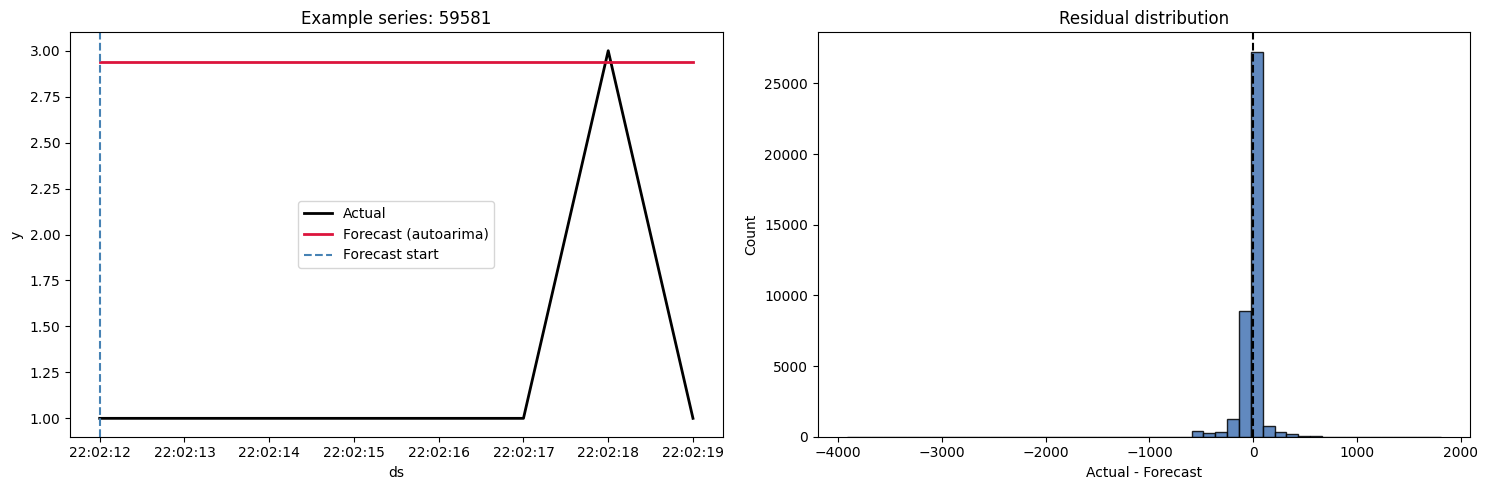

Run info saved to: e:\Cloud_Resource_Optimisation_thesis\results\nixtla_run_info.json
Selected model    : naive
Forecast rows     : 39,867
Common series     : 153
Residual mean     : -25.0491
Residual std      : 109.1444


In [24]:
if metrics_table.empty or forecast_eval.empty:
    raise ValueError('Nothing to visualize: metrics_table or forecast_eval is empty.')

force_regen_flag = bool(globals().get('force_regenerate_forecasts', False))
selected_model_flag = str(globals().get('selected_model', metrics_table.iloc[0]['model']))

example_model = metrics_table.iloc[0]['model']
example_series_id = forecast_eval['unique_id'].value_counts().index[0]
example_actual = forecast_eval[forecast_eval['unique_id'] == example_series_id].sort_values('ds')
example_pred = forecast_eval[
    (forecast_eval['unique_id'] == example_series_id)
    & (forecast_eval['model'] == example_model)
].sort_values('ds')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(example_actual['ds'], example_actual['y'], label='Actual', color='black', linewidth=2)
axes[0].plot(example_pred['ds'], example_pred['y_hat'], label=f'Forecast ({example_model})', color='crimson', linewidth=2)
axes[0].axvline(example_pred['ds'].min(), color='steelblue', linestyle='--', label='Forecast start')
axes[0].set_title(f'Example series: {example_series_id}')
axes[0].set_xlabel('ds')
axes[0].set_ylabel('y')
axes[0].legend()

residuals = forecast_eval['y'] - forecast_eval['y_hat']
axes[1].hist(residuals, bins=50, color='#4575b4', alpha=0.85, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Actual - Forecast')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

run_info = {
    'source': 'raw Alibaba cluster trace',
    'dataset_path': str(PROCESSED_DIR / 'nixtla_job_panel.csv'),
    'train_split_path': str(train_split_path),
    'val_split_path': str(val_split_path),
    'forecast_artifact_path': str(forecast_artifact_path),
    'forecast_source': forecast_source,
    'force_regenerate_forecasts': force_regen_flag,
    'statsforecast_models_used': statsforecast_models_used,
    'selected_model_by_score': selected_model_flag,
    'metrics_path': str(metrics_csv),
    'metrics_common_series_path': str(metrics_common_csv),
    'model_selection_score_path': str(model_selection_csv),
    'common_series_count': int(len(common_series_ids)),
    'metrics_by_fold_path': str(metrics_by_fold_csv),
    'season_sweep_path': str(season_sweep_csv),
    'horizon': horizon,
    'season_length': season_length,
    'best_season_length_by_mae': best_season_length,
    'max_backtest_folds': max_backtest_folds,
    'candidate_season_lengths': candidate_season_lengths,
    'freq': 'S',
    'timeline_type': 'synthetic_relative_seconds',
    'features': metadata['feature_columns'],
    'package_flags': {
        'statsforecast_available': HAS_STATSFORECAST,
        'neuralforecast_available': HAS_NEURALFORECAST,
        'sklearn_available': HAS_SKLEARN
    }
}

run_info_path = RESULTS_DIR / 'nixtla_run_info.json'
with open(run_info_path, 'w', encoding='utf-8') as f:
    json.dump(run_info, f, indent=2)

print(f'Run info saved to: {run_info_path}')
print(f'Selected model    : {selected_model_flag}')
print(f'Forecast rows     : {len(forecast_eval):,}')
print(f'Common series     : {len(common_series_ids):,}')
print(f'Residual mean     : {residuals.mean():.4f}')
print(f'Residual std      : {residuals.std():.4f}')

## Next steps

1. Fit a Nixtla model on `nixtla_job_panel.csv` using `StatsForecast`, `MLForecast`, or `NeuralForecast`.
2. Replace the synthetic relative-second axis with a real event-time axis if a higher-fidelity timestamp source becomes available.
3. Compare the Nixtla forecast metrics against the LSTM baseline from `lstm_v3.ipynb`.
4. Extend the feature set with lagged demand, rolling windows, and job metadata if the forecasting package supports them directly.